In [1]:
# Gemeinsamen Merge repo-relativ laden
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Repository-Wurzel mit .git wurde nicht gefunden.")


MERGED_FILE = (
    find_repo_root()
    / "dataset"
    / "cleaned"
    / "merged"
    / "all_sources_attacks_merged_analysis_ready.csv"
)
if not MERGED_FILE.exists():
    raise FileNotFoundError(
        f"Merge-Datei fehlt: {MERGED_FILE}\n"
        "Bitte zuerst dataset/raw/Merge all files.ipynb vollständig ausführen."
    )

combined = pd.read_csv(MERGED_FILE, low_memory=False)
print("Loaded file:", MERGED_FILE)
print("Shape:", combined.shape)
display(combined.head())


Loaded file: d:\HS Hof files all sem\HS Hof files Sem 7\Data Anlayse & Mining\Repo\dataset\cleaned\merged\all_sources_attacks_merged_analysis_ready.csv
Shape: (4066498, 36)


,attack_id,patient_id,source_group,headache,migraine,symptoms_both_side_headache,symptoms_one_side_headache,symptoms_pulsating_headache,symptoms_dull_headache,attack_datetime,...,attack_date,year,month,month_name,weekday_num,weekday_name,season,week_start,migraine_group,age_group
0,117,72741515,AppOnly,True,False,False,False,True,False,2020-06-08,...,2020-06-08,2020,6,Juni,0,Montag,Sommer,2020-06-08,Nicht-Migraene,30-44
1,118,72741515,AppOnly,True,True,False,False,True,False,2020-06-09,...,2020-06-09,2020,6,Juni,1,Dienstag,Sommer,2020-06-08,Migraene,30-44
2,127,44203359,AppOnly,True,True,False,True,True,False,2020-06-19,...,2020-06-19,2020,6,Juni,4,Freitag,Sommer,2020-06-15,Migraene,45-59
3,128,44203359,AppOnly,True,True,False,True,True,False,2020-06-20,...,2020-06-20,2020,6,Juni,5,Samstag,Sommer,2020-06-15,Migraene,45-59
4,129,44203359,AppOnly,True,True,False,True,True,False,2020-06-21,...,2020-06-21,2020,6,Juni,6,Sonntag,Sommer,2020-06-15,Migraene,45-59


In [2]:
combined["attack_datetime"] = pd.to_datetime(combined["attack_datetime"], errors="coerce")
combined["age_reg"] = pd.to_numeric(combined["age_reg"], errors="coerce")
combined["intensity"] = pd.to_numeric(combined["intensity"], errors="coerce")
combined["duration"] = pd.to_numeric(combined["duration"], errors="coerce")

combined["attack_id"] = combined["attack_id"].astype(str).str.strip()
combined["patient_id"] = combined["patient_id"].astype(str).str.strip()


df_analysis = combined[
    (combined["age_reg"] >= 18)
    & (combined["attack_datetime"].notna())
].copy()

print("Rows after filter:", df_analysis.shape[0])
print("Unique patients:", df_analysis["patient_id"].nunique())

Rows after filter: 3956188
Unique patients: 61622


In [3]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

df_analysis["weekday"] = df_analysis["attack_datetime"].dt.day_name()
df_analysis["month"] = df_analysis["attack_datetime"].dt.month_name()
df_analysis["month_number"] = df_analysis["attack_datetime"].dt.month


def get_season(month_number):
    if month_number in [12, 1, 2]:
        return "Winter"
    elif month_number in [3, 4, 5]:
        return "Spring"
    elif month_number in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


df_analysis["season"] = df_analysis["month_number"].apply(get_season)

df_analysis["weekday"] = pd.Categorical(df_analysis["weekday"], categories=weekday_order, ordered=True)
df_analysis["month"] = pd.Categorical(df_analysis["month"], categories=month_order, ordered=True)
df_analysis["season"] = pd.Categorical(
    df_analysis["season"],
    categories=["Winter", "Spring", "Summer", "Autumn"],
    ordered=True
)

In [4]:
print("INTENSITY CHECK")
print("----------------")

print("Missing intensity values:", df_analysis["intensity"].isna().sum())
print("Missing intensity percentage:", round(df_analysis["intensity"].isna().mean() * 100, 2), "%")

print("Minimum intensity:", df_analysis["intensity"].min())
print("Maximum intensity:", df_analysis["intensity"].max())
print("Median intensity:", df_analysis["intensity"].median())

print("\nValue counts:")
display(df_analysis["intensity"].value_counts(dropna=False).sort_index())

INTENSITY CHECK
----------------
Missing intensity values: 0
Missing intensity percentage: 0.0 %
Minimum intensity: 0
Maximum intensity: 10
Median intensity: 4.0

Value counts:


intensity
0      27393
1     282215
2     499245
3     641938
4     625283
5     566188
6     462463
7     377599
8     278823
9     110948
10     84093
Name: count, dtype: int64

In [5]:
print("DURATION CHECK")
print("--------------")

duration = df_analysis["duration"]

total_attacks = len(df_analysis)
valid_duration_count = duration.notna().sum()
missing_duration_count = duration.isna().sum()

duration_1440_count = (duration == 1440).sum()

print("Total attack rows:", total_attacks)
print("Valid duration values:", valid_duration_count)
print("Missing duration values:", missing_duration_count)

print("\nMissing duration percentage of all attacks:",
      round(missing_duration_count / total_attacks * 100, 2), "%")

print("\nMinimum duration:", duration.min())
print("Maximum duration:", duration.max())
print("Median duration:", duration.median())

print("\nDuration == 1440 minutes means: 24 hours")
print("Number of attacks with duration == 1440:", duration_1440_count)

print("Percentage of all attacks with duration == 1440:",
      round(duration_1440_count / total_attacks * 100, 2), "%")

print("Percentage of valid duration values with duration == 1440:",
      round(duration_1440_count / valid_duration_count * 100, 2), "%")

print("\nDuration description:")
display(duration.describe())

DURATION CHECK
--------------
Total attack rows: 3956188
Valid duration values: 3956188
Missing duration values: 0

Missing duration percentage of all attacks: 0.0 %

Minimum duration: 60
Maximum duration: 1440
Median duration: 480.0

Duration == 1440 minutes means: 24 hours
Number of attacks with duration == 1440: 478276
Percentage of all attacks with duration == 1440: 12.09 %
Percentage of valid duration values with duration == 1440: 12.09 %

Duration description:


count    3.956188e+06
mean     5.927479e+02
std      4.144318e+02
min      6.000000e+01
25%      3.000000e+02
50%      4.800000e+02
75%      8.400000e+02
max      1.440000e+03
Name: duration, dtype: float64

In [6]:
print("Duration values below 0:", (df_analysis["duration"] < 0).sum())
print("Duration values above 1440:", (df_analysis["duration"] > 1440).sum())

print("\nTop 20 most common duration values:")
display(df_analysis["duration"].value_counts(dropna=False).head(20))

Duration values below 0: 0
Duration values above 1440: 0

Top 20 most common duration values:


duration
1440    478276
240     388932
360     358161
300     354249
180     298188
480     266532
420     225098
120     211282
600     203718
720     201699
540     158259
840     107323
660     104563
960     101645
780      97575
60       87480
900      85395
1080     59542
1020     56067
1200     40024
Name: count, dtype: int64

In [7]:
# ------------------------------------------------------------
# Calendar exposure table
# ------------------------------------------------------------
# This creates one row for every calendar day in our observation period.

start_date = df_analysis["attack_datetime"].min().date()
end_date = df_analysis["attack_datetime"].max().date()

calendar = pd.DataFrame({
    "date": pd.date_range(start=start_date, end=end_date, freq="D")
})

calendar["weekday"] = calendar["date"].dt.day_name()
calendar["month"] = calendar["date"].dt.month_name()
calendar["month_number"] = calendar["date"].dt.month
calendar["year_month"] = calendar["date"].dt.to_period("M")


def get_season(month_number):
    if month_number in [12, 1, 2]:
        return "Winter"
    elif month_number in [3, 4, 5]:
        return "Spring"
    elif month_number in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


calendar["season"] = calendar["month_number"].apply(get_season)

# Keep correct order
calendar["weekday"] = pd.Categorical(calendar["weekday"], categories=weekday_order, ordered=True)
calendar["month"] = pd.Categorical(calendar["month"], categories=month_order, ordered=True)
calendar["season"] = pd.Categorical(
    calendar["season"],
    categories=["Winter", "Spring", "Summer", "Autumn"],
    ordered=True
)

print("Observation period:", start_date, "to", end_date)
print("Total calendar days:", len(calendar))


# ------------------------------------------------------------
# Weekday counts + number of calendar weekdays
# ------------------------------------------------------------

weekday_counts = (
    df_analysis
    .groupby("weekday", observed=False)
    .agg(
        attacks=("attack_id", "count"),
        unique_patients=("patient_id", "nunique")
    )
    .reset_index()
)

weekday_counts["attack_percentage"] = round(
    weekday_counts["attacks"] / weekday_counts["attacks"].sum() * 100, 2
)

calendar_weekday_counts = (
    calendar
    .groupby("weekday", observed=False)
    .agg(
        number_of_calendar_weekdays=("date", "count")
    )
    .reset_index()
)

weekday_counts = weekday_counts.merge(
    calendar_weekday_counts,
    on="weekday",
    how="left"
)

weekday_counts["attacks_per_calendar_weekday"] = round(
    weekday_counts["attacks"] / weekday_counts["number_of_calendar_weekdays"], 2
)

display(weekday_counts)


# ------------------------------------------------------------
# Month counts + number of Januarys/Februarys/etc. + calendar days
# ------------------------------------------------------------

month_counts = (
    df_analysis
    .groupby("month", observed=False)
    .agg(
        attacks=("attack_id", "count"),
        unique_patients=("patient_id", "nunique")
    )
    .reset_index()
)

month_counts["attack_percentage"] = round(
    month_counts["attacks"] / month_counts["attacks"].sum() * 100, 2
)

calendar_month_counts = (
    calendar
    .groupby("month", observed=False)
    .agg(
        number_of_month_periods=("year_month", "nunique"),
        calendar_days_in_this_month=("date", "count")
    )
    .reset_index()
)

month_counts = month_counts.merge(
    calendar_month_counts,
    on="month",
    how="left"
)

month_counts["attacks_per_calendar_day"] = round(
    month_counts["attacks"] / month_counts["calendar_days_in_this_month"], 2
)

display(month_counts)


# ------------------------------------------------------------
# Season counts + number of month-periods in each season + calendar days
# ------------------------------------------------------------

season_counts = (
    df_analysis
    .groupby("season", observed=False)
    .agg(
        attacks=("attack_id", "count"),
        unique_patients=("patient_id", "nunique")
    )
    .reset_index()
)

season_counts["attack_percentage"] = round(
    season_counts["attacks"] / season_counts["attacks"].sum() * 100, 2
)

calendar_season_counts = (
    calendar
    .groupby("season", observed=False)
    .agg(
        number_of_month_periods_in_season=("year_month", "nunique"),
        calendar_days_in_season=("date", "count")
    )
    .reset_index()
)

season_counts = season_counts.merge(
    calendar_season_counts,
    on="season",
    how="left"
)

season_counts["attacks_per_calendar_day"] = round(
    season_counts["attacks"] / season_counts["calendar_days_in_season"], 2
)

display(season_counts)

Observation period: 2020-06-08 to 2026-02-15
Total calendar days: 2079


,weekday,attacks,unique_patients,attack_percentage,number_of_calendar_weekdays,attacks_per_calendar_weekday
0,Monday,544850,50392,13.77,297,1834.51
1,Tuesday,563836,50632,14.25,297,1898.44
2,Wednesday,584877,51094,14.78,297,1969.28
3,Thursday,581732,50919,14.70,297,1958.69
4,Friday,572366,50266,14.47,297,1927.16
5,Saturday,573942,49721,14.51,297,1932.46
6,Sunday,534585,49137,13.51,297,1799.95


,month,attacks,unique_patients,attack_percentage,number_of_month_periods,calendar_days_in_this_month,attacks_per_calendar_day
0,January,417293,34014,10.55,6,186,2243.51
1,February,328568,33328,8.31,6,156,2106.21
2,March,275492,23543,6.96,5,155,1777.37
3,April,275453,24190,6.96,5,150,1836.35
4,May,292515,25275,7.39,5,155,1887.19
5,June,290143,25733,7.33,6,173,1677.13
6,July,317237,27021,8.02,6,186,1705.58
7,August,326243,27452,8.25,6,186,1753.99
8,September,334785,28548,8.46,6,180,1859.92
9,October,361978,29830,9.15,6,186,1946.12


,season,attacks,unique_patients,attack_percentage,number_of_month_periods_in_season,calendar_days_in_season,attacks_per_calendar_day
0,Winter,1119179,42573,28.29,18,528,2119.66
1,Spring,843460,31797,21.32,15,460,1833.61
2,Summer,933623,34597,23.60,18,545,1713.07
3,Autumn,1059926,38622,26.79,18,546,1941.26


In [8]:
## Helper Function for IQR and Median 

def median_iqr_by_group(df, group_col):
    result = (
        df
        .groupby(group_col, observed=False)
        .agg(
            median_intensity=("intensity", "median"),
            Q1_intensity=("intensity", lambda x: x.quantile(0.25)),
            Q3_intensity=("intensity", lambda x: x.quantile(0.75)),
            median_duration=("duration", "median"),
            Q1_duration=("duration", lambda x: x.quantile(0.25)),
            Q3_duration=("duration", lambda x: x.quantile(0.75))
        )
        .reset_index()
    )

    result["IQR_intensity"] = result["Q3_intensity"] - result["Q1_intensity"]
    result["IQR_duration"] = result["Q3_duration"] - result["Q1_duration"]

    return result

weekday_intensity_duration = median_iqr_by_group(df_analysis, "weekday")

display(weekday_intensity_duration)

month_intensity_duration = median_iqr_by_group(df_analysis, "month")

display(month_intensity_duration)

season_intensity_duration = median_iqr_by_group(df_analysis, "season")

display(season_intensity_duration)

,weekday,median_intensity,Q1_intensity,Q3_intensity,median_duration,Q1_duration,Q3_duration,IQR_intensity,IQR_duration
0,Monday,4.0,3.0,6.0,480.0,240.0,840.0,3.0,600.0
1,Tuesday,4.0,3.0,6.0,480.0,300.0,840.0,3.0,540.0
2,Wednesday,4.0,3.0,6.0,480.0,300.0,840.0,3.0,540.0
3,Thursday,4.0,3.0,6.0,480.0,300.0,840.0,3.0,540.0
4,Friday,4.0,3.0,6.0,480.0,300.0,840.0,3.0,540.0
5,Saturday,4.0,3.0,6.0,480.0,240.0,840.0,3.0,600.0
6,Sunday,4.0,3.0,6.0,480.0,240.0,840.0,3.0,600.0


,month,median_intensity,Q1_intensity,Q3_intensity,median_duration,Q1_duration,Q3_duration,IQR_intensity,IQR_duration
0,January,4.0,3.0,6.0,480.0,300.0,840.0,3.0,540.0
1,February,4.0,3.0,6.0,480.0,300.0,840.0,3.0,540.0
2,March,4.0,3.0,6.0,480.0,300.0,840.0,3.0,540.0
3,April,4.0,3.0,6.0,480.0,240.0,840.0,3.0,600.0
4,May,4.0,3.0,6.0,480.0,240.0,780.0,3.0,540.0
5,June,4.0,3.0,6.0,480.0,240.0,780.0,3.0,540.0
6,July,4.0,3.0,6.0,480.0,240.0,780.0,3.0,540.0
7,August,4.0,3.0,6.0,480.0,240.0,780.0,3.0,540.0
8,September,4.0,3.0,6.0,480.0,300.0,840.0,3.0,540.0
9,October,4.0,3.0,6.0,480.0,300.0,840.0,3.0,540.0


,season,median_intensity,Q1_intensity,Q3_intensity,median_duration,Q1_duration,Q3_duration,IQR_intensity,IQR_duration
0,Winter,4.0,3.0,6.0,480.0,300.0,840.0,3.0,540.0
1,Spring,4.0,3.0,6.0,480.0,240.0,840.0,3.0,600.0
2,Summer,4.0,3.0,6.0,480.0,240.0,780.0,3.0,540.0
3,Autumn,4.0,3.0,6.0,480.0,300.0,840.0,3.0,540.0


In [9]:
import matplotlib.pyplot as plt

def boxplot_by_group(df, group_col, value_col, group_order, title, ylabel, showfliers=False):
    plot_data = []
    labels = []

    for group in group_order:
        values = df.loc[df[group_col] == group, value_col].dropna()

        if len(values) > 0:
            plot_data.append(values)
            labels.append(group)

    plt.figure(figsize=(max(8, len(labels) * 0.9), 5))

    plt.boxplot(
        plot_data,
        labels=labels,
        showfliers=showfliers
    )

    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel(ylabel)

    if len(labels) > 7:
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

C:\Users\prath\AppData\Local\Temp\ipykernel_28984\967899911.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


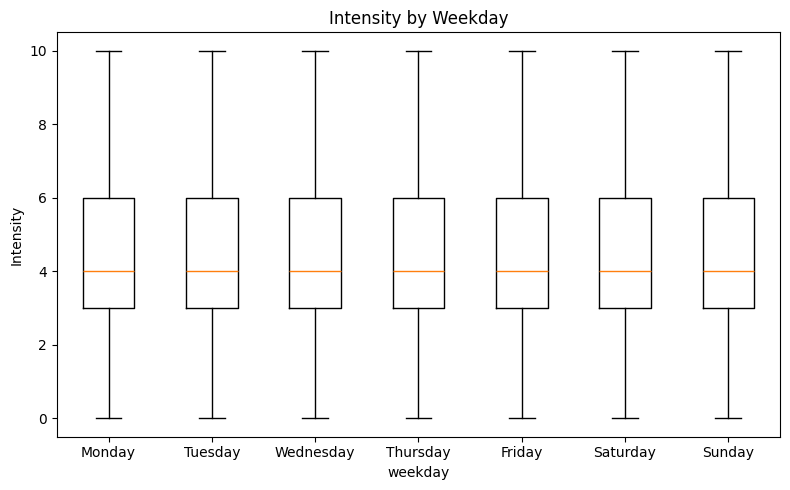

C:\Users\prath\AppData\Local\Temp\ipykernel_28984\967899911.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


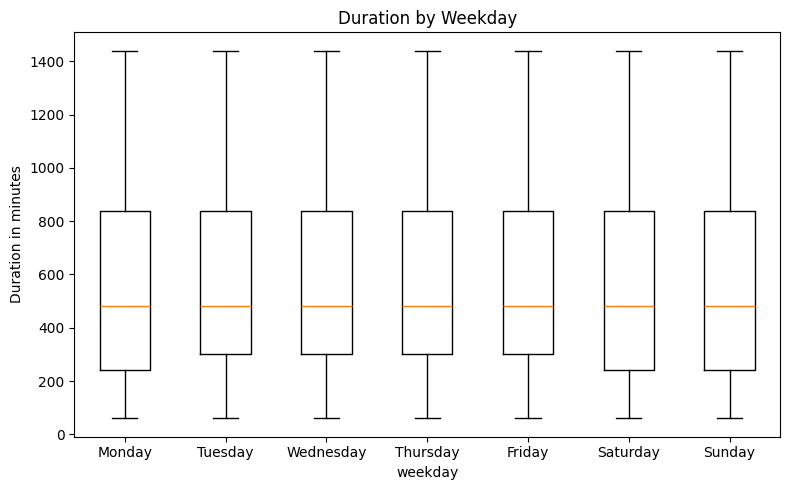

In [10]:
boxplot_by_group(
    df=df_analysis,
    group_col="weekday",
    value_col="intensity",
    group_order=weekday_order,
    title="Intensity by Weekday",
    ylabel="Intensity",
    showfliers=False
)

boxplot_by_group(
    df=df_analysis,
    group_col="weekday",
    value_col="duration",
    group_order=weekday_order,
    title="Duration by Weekday",
    ylabel="Duration in minutes",
    showfliers=False
)

C:\Users\prath\AppData\Local\Temp\ipykernel_28984\967899911.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


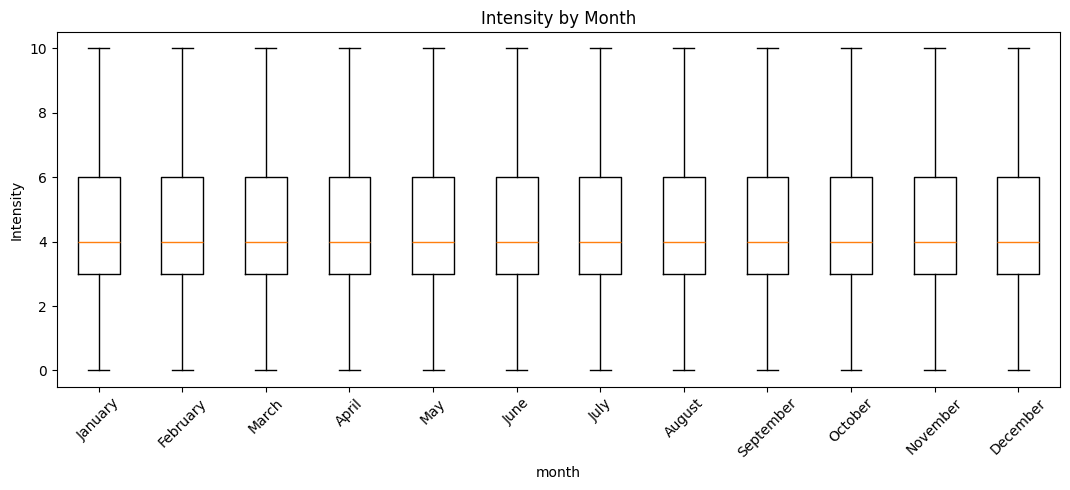

C:\Users\prath\AppData\Local\Temp\ipykernel_28984\967899911.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


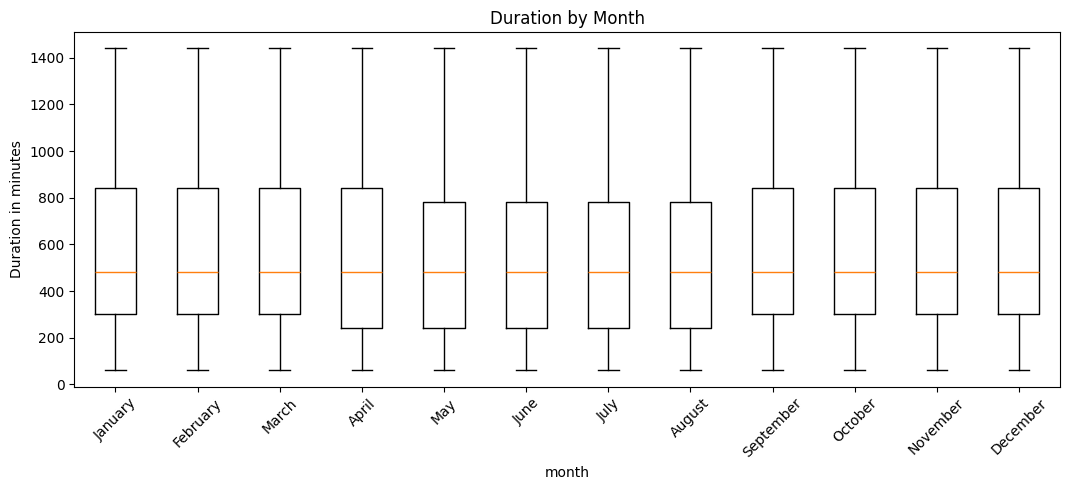

In [11]:
boxplot_by_group(
    df=df_analysis,
    group_col="month",
    value_col="intensity",
    group_order=month_order,
    title="Intensity by Month",
    ylabel="Intensity",
    showfliers=False
)

boxplot_by_group(
    df=df_analysis,
    group_col="month",
    value_col="duration",
    group_order=month_order,
    title="Duration by Month",
    ylabel="Duration in minutes",
    showfliers=False
)

C:\Users\prath\AppData\Local\Temp\ipykernel_28984\967899911.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


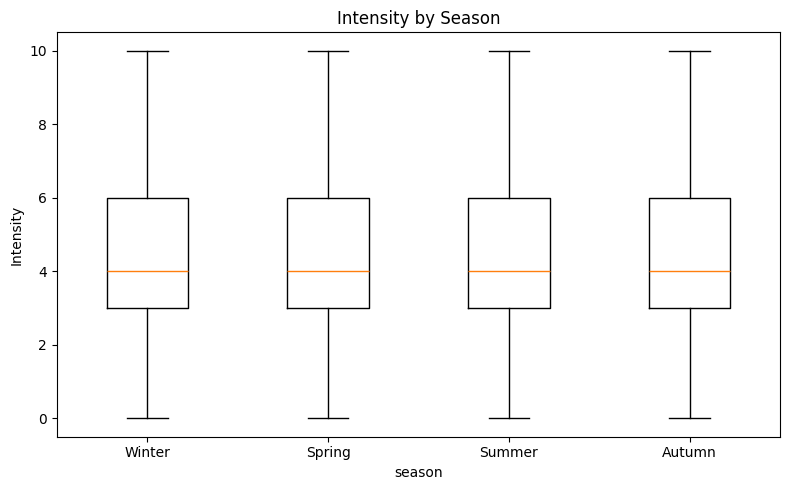

C:\Users\prath\AppData\Local\Temp\ipykernel_28984\967899911.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


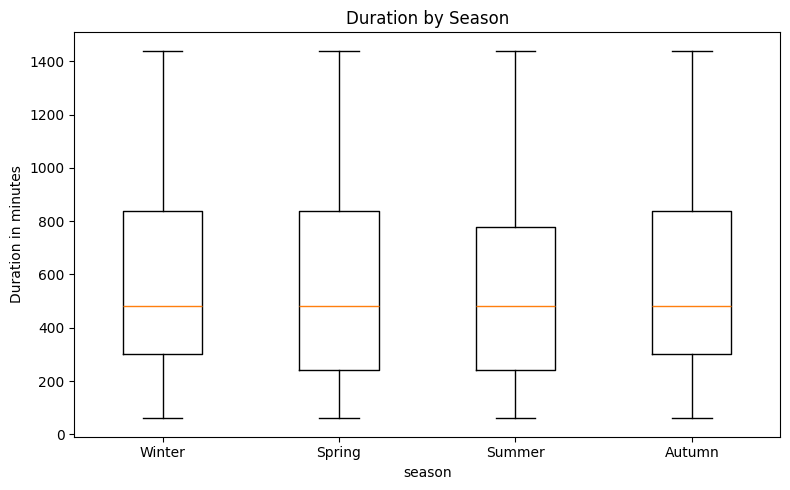

In [12]:
boxplot_by_group(
    df=df_analysis,
    group_col="season",
    value_col="intensity",
    group_order=["Winter", "Spring", "Summer", "Autumn"],
    title="Intensity by Season",
    ylabel="Intensity",
    showfliers=False
)

boxplot_by_group(
    df=df_analysis,
    group_col="season",
    value_col="duration",
    group_order=["Winter", "Spring", "Summer", "Autumn"],
    title="Duration by Season",
    ylabel="Duration in minutes",
    showfliers=False
)

In [13]:
from scipy.stats import kruskal

def run_kruskal_test(df, value_col, group_col, group_order):
    """
    Runs one Kruskal-Wallis test.

    value_col = numeric variable, e.g. intensity or duration
    group_col = grouping variable, e.g. weekday, month, season
    group_order = correct order of groups
    """

    groups = []
    group_sizes = []

    for group in group_order:
        values = df.loc[df[group_col] == group, value_col].dropna()

        if len(values) > 0:
            groups.append(values)
            group_sizes.append({
                "group": group,
                "n_values(Attacken)": len(values)
            })

    # Safety check: Kruskal-Wallis needs at least 2 groups
    if len(groups) < 2:
        return None, pd.DataFrame(group_sizes)

    # Run Kruskal-Wallis test
    H_statistic, p_value = kruskal(*groups)

    result = {
        "outcome": value_col,
        "group_variable": group_col,
        "number_of_groups": len(groups),
        "total_valid_values": sum(len(g) for g in groups),
        "H_statistic": H_statistic,
        "df": len(groups) - 1,
        "p_raw": p_value
    }

    return result, pd.DataFrame(group_sizes)

In [14]:
# ------------------------------------------------------------
# Step 4: Kruskal-Wallis tests
# ------------------------------------------------------------
# Significance level:
# alpha = 0.05 means we accept a 5% risk of rejecting H0 by chance.
# This corresponds to a 95% confidence level.

ALPHA = 0.05
CONFIDENCE_LEVEL = 1 - ALPHA

season_order = ["Winter", "Spring", "Summer", "Autumn"]

tests_to_run = [
    ("intensity", "weekday", weekday_order),
    ("intensity", "month", month_order),
    ("intensity", "season", season_order),
    ("duration", "weekday", weekday_order),
    ("duration", "month", month_order),
    ("duration", "season", season_order),
]

kruskal_results_list = []

for value_col, group_col, group_order in tests_to_run:
    result, group_sizes = run_kruskal_test(
        df=df_analysis,
        value_col=value_col,
        group_col=group_col,
        group_order=group_order
    )

    print("\n" + "=" * 70)
    print(f"Kruskal-Wallis test: {value_col} by {group_col}")
    print("=" * 70)

    print(f"Significance level alpha: {ALPHA}")
    print(f"Confidence level: {CONFIDENCE_LEVEL * 100:.0f}%")

    print("\nHypotheses:")
    print(f"H0: The distribution of {value_col} is the same across all {group_col} groups.")
    print(f"H1: At least one {group_col} group differs in the distribution of {value_col}.")

    print("\nGroup sizes after removing missing values:")
    display(group_sizes)

    if result is not None:
        kruskal_results_list.append(result)

        print("\nTest result:")
        print("H statistic:", result["H_statistic"])
        print("df:", result["df"])
        print("raw p-value:", result["p_raw"])

        print("\nPreliminary decision based on raw p-value:")
        if result["p_raw"] < ALPHA:
            print("p < alpha → reject H0 before multiple-testing correction.")
            print("Interpretation: There is a statistically detectable difference between at least some groups.")
        else:
            print("p >= alpha → do not reject H0 before multiple-testing correction.")
            print("Interpretation: No statistically detectable group difference found.")

    else:
        print("Test could not be run because fewer than 2 groups had valid values.")


Kruskal-Wallis test: intensity by weekday
Significance level alpha: 0.05
Confidence level: 95%

Hypotheses:
H0: The distribution of intensity is the same across all weekday groups.
H1: At least one weekday group differs in the distribution of intensity.

Group sizes after removing missing values:


,group,n_values(Attacken)
0,Monday,544850
1,Tuesday,563836
2,Wednesday,584877
3,Thursday,581732
4,Friday,572366
5,Saturday,573942
6,Sunday,534585



Test result:
H statistic: 323.0807507553269
df: 6
raw p-value: 9.221792123969262e-67

Preliminary decision based on raw p-value:
p < alpha → reject H0 before multiple-testing correction.
Interpretation: There is a statistically detectable difference between at least some groups.

Kruskal-Wallis test: intensity by month
Significance level alpha: 0.05
Confidence level: 95%

Hypotheses:
H0: The distribution of intensity is the same across all month groups.
H1: At least one month group differs in the distribution of intensity.

Group sizes after removing missing values:


,group,n_values(Attacken)
0,January,417293
1,February,328568
2,March,275492
3,April,275453
4,May,292515
5,June,290143
6,July,317237
7,August,326243
8,September,334785
9,October,361978



Test result:
H statistic: 38.362284901550595
df: 11
raw p-value: 6.795007613549655e-05

Preliminary decision based on raw p-value:
p < alpha → reject H0 before multiple-testing correction.
Interpretation: There is a statistically detectable difference between at least some groups.

Kruskal-Wallis test: intensity by season
Significance level alpha: 0.05
Confidence level: 95%

Hypotheses:
H0: The distribution of intensity is the same across all season groups.
H1: At least one season group differs in the distribution of intensity.

Group sizes after removing missing values:


...


Test result:
H statistic: 109.36555469349429
df: 6
raw p-value: 2.7677277738415835e-21

Preliminary decision based on raw p-value:
p < alpha → reject H0 before multiple-testing correction.
Interpretation: There is a statistically detectable difference between at least some groups.

Kruskal-Wallis test: duration by month
Significance level alpha: 0.05
Confidence level: 95%

Hypotheses:
H0: The distribution of duration is the same across all month groups.
H1: At least one month group differs in the distribution of duration.

Group sizes after removing missing values:


,group,n_values(Attacken)
0,January,417293
1,February,328568
2,March,275492
3,April,275453
4,May,292515
5,June,290143
6,July,317237
7,August,326243
8,September,334785
9,October,361978



Test result:
H statistic: 584.9578421021965
df: 11
raw p-value: 2.3083294538514966e-118

Preliminary decision based on raw p-value:
p < alpha → reject H0 before multiple-testing correction.
Interpretation: There is a statistically detectable difference between at least some groups.

Kruskal-Wallis test: duration by season
Significance level alpha: 0.05
Confidence level: 95%

Hypotheses:
H0: The distribution of duration is the same across all season groups.
H1: At least one season group differs in the distribution of duration.

Group sizes after removing missing values:


,group,n_values(Attacken)
0,Winter,1119179
1,Spring,843460
2,Summer,933623
3,Autumn,1059926



Test result:
H statistic: 465.33430401580745
df: 3
raw p-value: 1.55128882770017e-100

Preliminary decision based on raw p-value:
p < alpha → reject H0 before multiple-testing correction.
Interpretation: There is a statistically detectable difference between at least some groups.


In [15]:
kruskal_results = pd.DataFrame(kruskal_results_list)

# Show p-values in scientific notation for readability
kruskal_results["p_raw_scientific"] = kruskal_results["p_raw"].apply(lambda p: f"{p:.3e}")

display(kruskal_results)

,outcome,group_variable,number_of_groups,total_valid_values,H_statistic,df,p_raw,p_raw_scientific
0,intensity,weekday,7,3956188,323.080751,6,9.221792e-67,9.222e-67
1,intensity,month,12,3956188,38.362285,11,6.795008e-05,6.795e-05
2,intensity,season,4,3956188,16.126829,3,1.068069e-03,1.068e-03
3,duration,weekday,7,3956188,109.365555,6,2.767728e-21,2.768e-21
4,duration,month,12,3956188,584.957842,11,2.308329e-118,2.308e-118
5,duration,season,4,3956188,465.334304,3,1.551289e-100,1.551e-100


In [16]:
# ------------------------------------------------------------
# Step 5: Effect sizes for Kruskal-Wallis tests
# ------------------------------------------------------------
# Epsilon squared tells us how large the group effect is.
# It helps us judge whether a statistically significant result is also practically relevant.

def calculate_epsilon_squared(H, k, n):
    """
    Calculates epsilon squared for a Kruskal-Wallis test.

    H = Kruskal-Wallis H statistic
    k = number of groups
    n = total number of valid observations
    """
    epsilon_squared = (H - k + 1) / (n - k)

    # Very small negative values can happen mathematically in edge cases.
    # Effect size should not be negative, so we limit it to minimum 0.
    epsilon_squared = max(0, epsilon_squared)

    return epsilon_squared


kruskal_results["epsilon_squared"] = kruskal_results.apply(
    lambda row: calculate_epsilon_squared(
        H=row["H_statistic"],
        k=row["number_of_groups"],
        n=row["total_valid_values"]
    ),
    axis=1
)

kruskal_results["epsilon_squared_percent"] = kruskal_results["epsilon_squared"] * 100

display(kruskal_results)

,outcome,group_variable,number_of_groups,total_valid_values,H_statistic,df,p_raw,p_raw_scientific,epsilon_squared,epsilon_squared_percent
0,intensity,weekday,7,3956188,323.080751,6,9.221792e-67,9.222e-67,0.000080,0.008015
1,intensity,month,12,3956188,38.362285,11,6.795008e-05,6.795e-05,0.000007,0.000692
2,intensity,season,4,3956188,16.126829,3,1.068069e-03,1.068e-03,0.000003,0.000332
3,duration,weekday,7,3956188,109.365555,6,2.767728e-21,2.768e-21,0.000026,0.002613
4,duration,month,12,3956188,584.957842,11,2.308329e-118,2.308e-118,0.000145,0.014508
5,duration,season,4,3956188,465.334304,3,1.551289e-100,1.551e-100,0.000117,0.011686


In [17]:
def interpret_epsilon_squared(epsilon):
    """
    Gives a simple interpretation of epsilon squared.
    These are rough orientation values, not strict medical rules.
    """
    if epsilon < 0.01:
        return "very small / negligible"
    elif epsilon < 0.06:
        return "small"
    elif epsilon < 0.14:
        return "medium"
    else:
        return "large"


kruskal_results["effect_size_interpretation"] = kruskal_results["epsilon_squared"].apply(
    interpret_epsilon_squared
)

display(kruskal_results)

,outcome,group_variable,number_of_groups,total_valid_values,H_statistic,df,p_raw,p_raw_scientific,epsilon_squared,epsilon_squared_percent,effect_size_interpretation
0,intensity,weekday,7,3956188,323.080751,6,9.221792e-67,9.222e-67,0.000080,0.008015,very small / negligible
1,intensity,month,12,3956188,38.362285,11,6.795008e-05,6.795e-05,0.000007,0.000692,very small / negligible
2,intensity,season,4,3956188,16.126829,3,1.068069e-03,1.068e-03,0.000003,0.000332,very small / negligible
3,duration,weekday,7,3956188,109.365555,6,2.767728e-21,2.768e-21,0.000026,0.002613,very small / negligible
4,duration,month,12,3956188,584.957842,11,2.308329e-118,2.308e-118,0.000145,0.014508,very small / negligible
5,duration,season,4,3956188,465.334304,3,1.551289e-100,1.551e-100,0.000117,0.011686,very small / negligible


In [18]:
# ------------------------------------------------------------
# Step 6: Holm correction for multiple testing
# ------------------------------------------------------------
# We performed 6 Kruskal-Wallis tests.
# Holm correction adjusts the p-values so that we reduce the risk
# of false-positive findings caused by multiple testing.

def holm_correction(p_values):
    """
    Manual Holm-Bonferroni correction.

    Input:
        p_values = list or pandas Series of raw p-values

    Output:
        Holm-adjusted p-values in the original order
    """

    p_values = np.array(p_values)
    m = len(p_values)

    # Sort p-values from smallest to largest
    sorted_indices = np.argsort(p_values)
    sorted_p_values = p_values[sorted_indices]

    adjusted_sorted_p_values = np.empty(m)

    # Holm adjustment:
    # smallest p-value gets multiplied by m
    # second-smallest by m-1
    # third-smallest by m-2, etc.
    for i in range(m):
        adjusted_sorted_p_values[i] = sorted_p_values[i] * (m - i)

    # Make adjusted p-values monotonic increasing
    adjusted_sorted_p_values = np.maximum.accumulate(adjusted_sorted_p_values)

    # p-values cannot be greater than 1
    adjusted_sorted_p_values = np.minimum(adjusted_sorted_p_values, 1)

    # Put adjusted p-values back into original order
    adjusted_p_values = np.empty(m)
    adjusted_p_values[sorted_indices] = adjusted_sorted_p_values

    return adjusted_p_values

kruskal_results["p_holm"] = holm_correction(kruskal_results["p_raw"])

kruskal_results["p_holm_scientific"] = kruskal_results["p_holm"].apply(
    lambda p: f"{p:.3e}"
)

kruskal_results["significant_after_holm"] = kruskal_results["p_holm"] < ALPHA

display(kruskal_results)

,outcome,group_variable,number_of_groups,total_valid_values,H_statistic,df,p_raw,p_raw_scientific,epsilon_squared,epsilon_squared_percent,effect_size_interpretation,p_holm,p_holm_scientific,significant_after_holm
0,intensity,weekday,7,3956188,323.080751,6,9.221792e-67,9.222e-67,0.000080,0.008015,very small / negligible,3.688717e-66,3.689e-66,True
1,intensity,month,12,3956188,38.362285,11,6.795008e-05,6.795e-05,0.000007,0.000692,very small / negligible,1.359002e-04,1.359e-04,True
2,intensity,season,4,3956188,16.126829,3,1.068069e-03,1.068e-03,0.000003,0.000332,very small / negligible,1.068069e-03,1.068e-03,True
3,duration,weekday,7,3956188,109.365555,6,2.767728e-21,2.768e-21,0.000026,0.002613,very small / negligible,8.303183e-21,8.303e-21,True
4,duration,month,12,3956188,584.957842,11,2.308329e-118,2.308e-118,0.000145,0.014508,very small / negligible,1.384998e-117,1.385e-117,True
5,duration,season,4,3956188,465.334304,3,1.551289e-100,1.551e-100,0.000117,0.011686,very small / negligible,7.756444e-100,7.756e-100,True


In [19]:
final_fq3_results = kruskal_results[
    [
        "outcome",
        "group_variable",
        "H_statistic",
        "df",
        "p_raw",
        "p_raw_scientific",
        "p_holm",
        "p_holm_scientific",
        "epsilon_squared",
        "epsilon_squared_percent",
        "effect_size_interpretation",
        "significant_after_holm"
    ]
].copy()

final_fq3_results["H_statistic"] = final_fq3_results["H_statistic"].round(3)
final_fq3_results["epsilon_squared"] = final_fq3_results["epsilon_squared"].round(8)
final_fq3_results["epsilon_squared_percent"] = final_fq3_results["epsilon_squared_percent"].round(4)

display(final_fq3_results)



for _, row in final_fq3_results.iterrows():
    print("--------------------------------------------------")
    print(f"Outcome: {row['outcome']}")
    print(f"Group variable: {row['group_variable']}")
    print(f"H({int(row['df'])}) = {row['H_statistic']}")
    print(f"raw p-value = {row['p_raw_scientific']}")
    print(f"Holm-corrected p-value = {row['p_holm_scientific']}")
    print(f"epsilon² = {row['epsilon_squared']} ({row['epsilon_squared_percent']}%)")
    print(f"Effect size: {row['effect_size_interpretation']}")

    if row["significant_after_holm"]:
        print("Decision: significant after Holm correction")
    else:
        print("Decision: not significant after Holm correction")

,outcome,group_variable,H_statistic,df,p_raw,p_raw_scientific,p_holm,p_holm_scientific,epsilon_squared,epsilon_squared_percent,effect_size_interpretation,significant_after_holm
0,intensity,weekday,323.081,6,9.221792e-67,9.222e-67,3.688717e-66,3.689e-66,0.000080,0.0080,very small / negligible,True
1,intensity,month,38.362,11,6.795008e-05,6.795e-05,1.359002e-04,1.359e-04,0.000007,0.0007,very small / negligible,True
2,intensity,season,16.127,3,1.068069e-03,1.068e-03,1.068069e-03,1.068e-03,0.000003,0.0003,very small / negligible,True
3,duration,weekday,109.366,6,2.767728e-21,2.768e-21,8.303183e-21,8.303e-21,0.000026,0.0026,very small / negligible,True
4,duration,month,584.958,11,2.308329e-118,2.308e-118,1.384998e-117,1.385e-117,0.000145,0.0145,very small / negligible,True
5,duration,season,465.334,3,1.551289e-100,1.551e-100,7.756444e-100,7.756e-100,0.000117,0.0117,very small / negligible,True


--------------------------------------------------
Outcome: intensity
Group variable: weekday
H(6) = 323.081
raw p-value = 9.222e-67
Holm-corrected p-value = 3.689e-66
epsilon² = 8.015e-05 (0.008%)
Effect size: very small / negligible
Decision: significant after Holm correction
--------------------------------------------------
Outcome: intensity
Group variable: month
H(11) = 38.362
raw p-value = 6.795e-05
Holm-corrected p-value = 1.359e-04
epsilon² = 6.92e-06 (0.0007%)
Effect size: very small / negligible
Decision: significant after Holm correction
--------------------------------------------------
Outcome: intensity
Group variable: season
H(3) = 16.127
raw p-value = 1.068e-03
Holm-corrected p-value = 1.068e-03
epsilon² = 3.32e-06 (0.0003%)
Effect size: very small / negligible
Decision: significant after Holm correction
--------------------------------------------------
Outcome: duration
Group variable: weekday
H(6) = 109.366
raw p-value = 2.768e-21
Holm-corrected p-value = 8.303e-21


In [20]:
# In Den oben geführten Tests wurde H(0) immer abgelehnt aber wo liegt genau der Unterschied?

def kruskal_group_contributions(df, value_col, group_col, group_order):
    """
    Shows which groups contribute most to the Kruskal-Wallis result.

    Important:
    Kruskal-Wallis works with ranks.
    Therefore, we calculate for each group:
    - median
    - IQR
    - mean rank
    - deviation from overall mean rank
    - contribution percentage to the Kruskal-Wallis group difference
    """

    tmp = df[[value_col, group_col]].dropna().copy()

    # Keep only expected groups
    tmp = tmp[tmp[group_col].isin(group_order)].copy()

    # Rank the outcome values
    tmp["_rank"] = tmp[value_col].rank(method="average")

    n_total = len(tmp)
    overall_mean_rank = (n_total + 1) / 2
    overall_median = tmp[value_col].median()

    group_summary = (
        tmp
        .groupby(group_col, observed=True)
        .agg(
            n=(value_col, "count"),
            median=(value_col, "median"),
            q1=(value_col, lambda x: x.quantile(0.25)),
            q3=(value_col, lambda x: x.quantile(0.75)),
            mean_rank=("_rank", "mean")
        )
        .reindex(group_order)
        .dropna(subset=["n"])
        .reset_index()
    )

    group_summary["iqr"] = group_summary["q3"] - group_summary["q1"]
    group_summary["median_difference_from_overall"] = (
        group_summary["median"] - overall_median
    )

    group_summary["mean_rank_difference_from_overall"] = (
        group_summary["mean_rank"] - overall_mean_rank
    )

    # Contribution to Kruskal-Wallis group separation
    group_summary["contribution_raw"] = (
        group_summary["n"]
        * group_summary["mean_rank_difference_from_overall"] ** 2
    )

    group_summary["contribution_percent"] = (
        group_summary["contribution_raw"]
        / group_summary["contribution_raw"].sum()
        * 100
    )

    group_summary["rank_direction"] = np.where(
        group_summary["mean_rank_difference_from_overall"] > 0,
        "higher than overall",
        "lower than overall"
    )

    group_summary = group_summary[
        [
            group_col,
            "n",
            "median",
            "q1",
            "q3",
            "iqr",
            "median_difference_from_overall",
            "mean_rank",
            "mean_rank_difference_from_overall",
            "rank_direction",
            "contribution_percent"
        ]
    ].copy()

    group_summary["median"] = group_summary["median"].round(3)
    group_summary["q1"] = group_summary["q1"].round(3)
    group_summary["q3"] = group_summary["q3"].round(3)
    group_summary["iqr"] = group_summary["iqr"].round(3)
    group_summary["median_difference_from_overall"] = (
        group_summary["median_difference_from_overall"].round(3)
    )
    group_summary["mean_rank"] = group_summary["mean_rank"].round(3)
    group_summary["mean_rank_difference_from_overall"] = (
        group_summary["mean_rank_difference_from_overall"].round(3)
    )
    group_summary["contribution_percent"] = (
        group_summary["contribution_percent"].round(2)
    )

    # Sort by contribution, strongest driver first
    group_summary = group_summary.sort_values(
        "contribution_percent",
        ascending=False
    )

    return group_summary

In [21]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]

driver_tests = [
    ("intensity", "weekday", weekday_order),
    ("intensity", "month", month_order),
    ("intensity", "season", season_order),
    ("duration", "weekday", weekday_order),
    ("duration", "month", month_order),
    ("duration", "season", season_order),
]

kruskal_driver_tables = {}

for value_col, group_col, group_order in driver_tests:
    table_name = f"{value_col}_by_{group_col}"

    driver_table = kruskal_group_contributions(
        df=df_analysis,
        value_col=value_col,
        group_col=group_col,
        group_order=group_order
    )

    kruskal_driver_tables[table_name] = driver_table

    print("\n" + "=" * 80)
    print(f"Main drivers for Kruskal-Wallis result: {value_col} by {group_col}")
    print("=" * 80)

    display(driver_table)


Main drivers for Kruskal-Wallis result: intensity by weekday


,weekday,n,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
6,Sunday,534585,4.0,3.0,6.0,3.0,0.0,1960967.507,-17126.993,lower than overall,37.83
4,Friday,572366,4.0,3.0,6.0,3.0,0.0,1987935.166,9840.666,higher than overall,13.37
3,Thursday,581732,4.0,3.0,6.0,3.0,0.0,1987688.957,9594.457,higher than overall,12.92
0,Monday,544850,4.0,3.0,6.0,3.0,0.0,1968705.078,-9389.422,lower than overall,11.59
1,Tuesday,563836,4.0,3.0,6.0,3.0,0.0,1969329.518,-8764.982,lower than overall,10.45
5,Saturday,573942,4.0,3.0,6.0,3.0,0.0,1986364.346,8269.846,higher than overall,9.47
2,Wednesday,584877,4.0,3.0,6.0,3.0,0.0,1983657.029,5562.529,higher than overall,4.37



Main drivers for Kruskal-Wallis result: intensity by month


,month,n,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
9,October,361978,4.0,3.0,6.0,3.0,0.0,1984772.222,6677.722,higher than overall,32.80
11,December,373318,4.0,3.0,6.0,3.0,0.0,1972057.254,-6037.246,lower than overall,27.65
2,March,275492,4.0,3.0,6.0,3.0,0.0,1983378.062,5283.562,higher than overall,15.63
7,August,326243,4.0,3.0,6.0,3.0,0.0,1973585.654,-4508.846,lower than overall,13.48
3,April,275453,4.0,3.0,6.0,3.0,0.0,1980635.950,2541.450,higher than overall,3.61
0,January,417293,4.0,3.0,6.0,3.0,0.0,1976376.675,-1717.825,lower than overall,2.50
6,July,317237,4.0,3.0,6.0,3.0,0.0,1976402.335,-1692.165,lower than overall,1.85
1,February,328568,4.0,3.0,6.0,3.0,0.0,1979659.177,1564.677,higher than overall,1.63
10,November,363163,4.0,3.0,6.0,3.0,0.0,1977304.231,-790.269,lower than overall,0.46
8,September,334785,4.0,3.0,6.0,3.0,0.0,1978836.763,742.263,higher than overall,0.37



Main drivers for Kruskal-Wallis result: intensity by season


...

,weekday,n,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
5,Saturday,573942,480.0,240.0,840.0,600.0,0.0,1968297.470,-9797.030,lower than overall,38.84
3,Thursday,581732,480.0,300.0,840.0,540.0,0.0,1987397.570,9303.070,higher than overall,35.50
0,Monday,544850,480.0,240.0,840.0,600.0,0.0,1972540.974,-5553.526,lower than overall,11.85
6,Sunday,534585,480.0,240.0,840.0,600.0,0.0,1982395.619,4301.119,higher than overall,6.97
1,Tuesday,563836,480.0,300.0,840.0,540.0,0.0,1975370.215,-2724.285,lower than overall,2.95
2,Wednesday,584877,480.0,300.0,840.0,540.0,0.0,1980675.743,2581.243,higher than overall,2.75
4,Friday,572366,480.0,300.0,840.0,540.0,0.0,1979778.561,1684.061,higher than overall,1.14



Main drivers for Kruskal-Wallis result: duration by month


,month,n,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
5,June,290143,480.0,240.0,780.0,540.0,0.0,1948978.181,-29116.319,lower than overall,32.42
1,February,328568,480.0,300.0,840.0,540.0,0.0,1996184.228,18089.728,higher than overall,14.17
9,October,361978,480.0,300.0,840.0,540.0,0.0,1992937.378,14842.878,higher than overall,10.51
7,August,326243,480.0,240.0,780.0,540.0,0.0,1962938.799,-15155.701,lower than overall,9.88
4,May,292515,480.0,240.0,780.0,540.0,0.0,1963043.854,-15050.646,lower than overall,8.73
6,July,317237,480.0,240.0,780.0,540.0,0.0,1964403.097,-13691.403,lower than overall,7.84
0,January,417293,480.0,300.0,840.0,540.0,0.0,1988250.943,10156.443,higher than overall,5.67
3,April,275453,480.0,240.0,840.0,600.0,0.0,1969320.265,-8774.235,lower than overall,2.80
8,September,334785,480.0,300.0,840.0,540.0,0.0,1985423.193,7328.693,higher than overall,2.37
10,November,363163,480.0,300.0,840.0,540.0,0.0,1984819.875,6725.375,higher than overall,2.17



Main drivers for Kruskal-Wallis result: duration by season


,season,n,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
2,Summer,933623,480.0,240.0,780.0,540.0,0.0,1959097.799,-18996.701,lower than overall,55.83
0,Winter,1119179,480.0,300.0,840.0,540.0,0.0,1989196.145,11101.645,higher than overall,22.86
3,Autumn,1059926,480.0,300.0,840.0,540.0,0.0,1987782.666,9688.166,higher than overall,16.49
1,Spring,843460,480.0,240.0,840.0,600.0,0.0,1972216.675,-5877.825,lower than overall,4.83


In [22]:
top_driver_summary_list = []

for value_col, group_col, group_order in driver_tests:
    table_name = f"{value_col}_by_{group_col}"
    driver_table = kruskal_driver_tables[table_name]

    top_groups = driver_table.head(3).copy()

    for _, row in top_groups.iterrows():
        top_driver_summary_list.append({
            "outcome": value_col,
            "group_variable": group_col,
            "driver_group": row[group_col],
            "median": row["median"],
            "median_difference_from_overall": row["median_difference_from_overall"],
            "rank_direction": row["rank_direction"],
            "contribution_percent": row["contribution_percent"]
        })

top_driver_summary = pd.DataFrame(top_driver_summary_list)

display(top_driver_summary)

,outcome,group_variable,driver_group,median,median_difference_from_overall,rank_direction,contribution_percent
0,intensity,weekday,Sunday,4.0,0.0,lower than overall,37.83
1,intensity,weekday,Friday,4.0,0.0,higher than overall,13.37
2,intensity,weekday,Thursday,4.0,0.0,higher than overall,12.92
3,intensity,month,October,4.0,0.0,higher than overall,32.80
4,intensity,month,December,4.0,0.0,lower than overall,27.65
5,intensity,month,March,4.0,0.0,higher than overall,15.63
6,intensity,season,Spring,4.0,0.0,higher than overall,26.18
7,intensity,season,Winter,4.0,0.0,lower than overall,26.06
8,intensity,season,Autumn,4.0,0.0,higher than overall,25.80
9,duration,weekday,Saturday,480.0,0.0,lower than overall,38.84


In [23]:
# ------------------------------------------------------------
# Step 7.1: Patient-level median tables
# ------------------------------------------------------------
# Goal:
# Reduce the influence of patients with many attack entries.
#
# Instead of:
# one row = one attack
#
# We create:
# one row = one patient + one time group
#
# Example:
# patient_id + Monday -> median intensity and median duration for this patient on Mondays


def create_patient_level_medians(df, group_col):
    patient_level_table = (
        df
        .groupby(["patient_id", group_col], observed=True)
        .agg(
            patient_median_intensity=("intensity", "median"),
            patient_median_duration=("duration", "median"),
            n_attacks_in_group=("attack_id", "count")
        )
        .reset_index()
    )

    # Keep only real patient-time-group combinations with at least one attack
    patient_level_table = patient_level_table[
        patient_level_table["n_attacks_in_group"] > 0
    ].copy()

    return patient_level_table

# Create three tables

patient_weekday_medians = create_patient_level_medians(df_analysis, "weekday")
patient_month_medians = create_patient_level_medians(df_analysis, "month")
patient_season_medians = create_patient_level_medians(df_analysis, "season")

# Display first rows out of the Table

print("Patient-level weekday medians:")
display(patient_weekday_medians.head())

print("Patient-level month medians:")
display(patient_month_medians.head())

print("Patient-level season medians:")
display(patient_season_medians.head())

# n_attacks_in_group erklärt wie viel Attackeinträge genutzt wurden für  den jeweiligen Patient Median berechung

Patient-level weekday medians:


,patient_id,weekday,patient_median_intensity,patient_median_duration,n_attacks_in_group
0,10005187,Monday,2.0,180.0,1
1,10005187,Tuesday,5.0,360.0,3
2,10005187,Wednesday,5.0,120.0,1
3,10005187,Friday,6.0,420.0,1
4,10005187,Saturday,7.0,240.0,1


Patient-level month medians:


,patient_id,month,patient_median_intensity,patient_median_duration,n_attacks_in_group
0,10005187,April,5.5,240.0,4
1,10005187,May,5.0,180.0,5
2,10005708,September,5.0,150.0,6
3,10005708,October,3.0,780.0,3
4,10005708,November,2.0,180.0,1


Patient-level season medians:


,patient_id,season,patient_median_intensity,patient_median_duration,n_attacks_in_group
0,10005187,Spring,5.0,240.0,9
1,10005708,Autumn,3.0,180.0,10
2,10005818,Winter,4.0,1080.0,1
3,10005818,Spring,7.0,1080.0,9
4,10005818,Summer,4.0,450.0,6


In [24]:
print("Rows in patient_weekday_medians:", patient_weekday_medians.shape[0])
print("Rows in patient_month_medians:", patient_month_medians.shape[0])
print("Rows in patient_season_medians:", patient_season_medians.shape[0])

print("\nUnique patients in weekday table:", patient_weekday_medians["patient_id"].nunique())
print("Unique patients in month table:", patient_month_medians["patient_id"].nunique())
print("Unique patients in season table:", patient_season_medians["patient_id"].nunique())

max_weekday_rows = df_analysis["patient_id"].nunique() * 7
max_month_rows = df_analysis["patient_id"].nunique() * 12
max_season_rows = df_analysis["patient_id"].nunique() * 4

coverage_summary = pd.DataFrame({
    "table": ["weekday", "month", "season"],
    "actual_rows": [
        patient_weekday_medians.shape[0],
        patient_month_medians.shape[0],
        patient_season_medians.shape[0]
    ],
    "maximum_possible_rows": [
        max_weekday_rows,
        max_month_rows,
        max_season_rows
    ]
})

coverage_summary["coverage_percent"] = round(
    coverage_summary["actual_rows"] / coverage_summary["maximum_possible_rows"] * 100,
    2
)

coverage_summary["average_groups_per_patient"] = round(
    coverage_summary["actual_rows"] / df_analysis["patient_id"].nunique(),
    2
)

display(coverage_summary)

Rows in patient_weekday_medians: 352161
Rows in patient_month_medians: 340779
Rows in patient_season_medians: 147589

Unique patients in weekday table: 61622
Unique patients in month table: 61622
Unique patients in season table: 61622


,table,actual_rows,maximum_possible_rows,coverage_percent,average_groups_per_patient
0,weekday,352161,431354,81.64,5.71
1,month,340779,739464,46.08,5.53
2,season,147589,246488,59.88,2.40


In [25]:
print("Attack counts used per patient-time-group: weekday")
display(patient_weekday_medians["n_attacks_in_group"].describe())

print("Attack counts used per patient-time-group: month")
display(patient_month_medians["n_attacks_in_group"].describe())

print("Attack counts used per patient-time-group: season")
display(patient_season_medians["n_attacks_in_group"].describe())

Attack counts used per patient-time-group: weekday


count    352161.000000
mean         11.234032
std          17.916728
min           1.000000
25%           2.000000
50%           5.000000
75%          13.000000
max         283.000000
Name: n_attacks_in_group, dtype: float64

Attack counts used per patient-time-group: month


count    340779.000000
mean         11.609248
std          13.101840
min           1.000000
25%           4.000000
50%           8.000000
75%          15.000000
max         186.000000
Name: n_attacks_in_group, dtype: float64

Attack counts used per patient-time-group: season


count    147589.000000
mean         26.805439
std          35.623567
min           1.000000
25%           6.000000
50%          15.000000
75%          34.000000
max         531.000000
Name: n_attacks_in_group, dtype: float64

In [26]:
# again helper function

def run_patient_level_kruskal_test(df, value_col, group_col, group_order):
    """
    Runs one Kruskal-Wallis test on patient-level median values.

    df = patient-level median table
    value_col = patient_median_intensity or patient_median_duration
    group_col = weekday, month, or season
    group_order = correct order of groups
    """

    groups = []
    group_sizes = []

    for group in group_order:
        values = df.loc[df[group_col] == group, value_col].dropna()

        if len(values) > 0:
            groups.append(values)
            group_sizes.append({
                "group": group,
                "n_patient_median_values": len(values)
            })

    if len(groups) < 2:
        return None, pd.DataFrame(group_sizes)

    H_statistic, p_value = kruskal(*groups)

    result = {
        "outcome": value_col,
        "group_variable": group_col,
        "number_of_groups": len(groups),
        "total_valid_values": sum(len(g) for g in groups),
        "H_statistic": H_statistic,
        "df": len(groups) - 1,
        "p_raw": p_value
    }

    return result, pd.DataFrame(group_sizes)

# patient weighted Test defined here...

season_order = ["Winter", "Spring", "Summer", "Autumn"]

patient_weighted_tests_to_run = [
    (
        patient_weekday_medians,
        "patient_median_intensity",
        "weekday",
        weekday_order
    ),
    (
        patient_month_medians,
        "patient_median_intensity",
        "month",
        month_order
    ),
    (
        patient_season_medians,
        "patient_median_intensity",
        "season",
        season_order
    ),
    (
        patient_weekday_medians,
        "patient_median_duration",
        "weekday",
        weekday_order
    ),
    (
        patient_month_medians,
        "patient_median_duration",
        "month",
        month_order
    ),
    (
        patient_season_medians,
        "patient_median_duration",
        "season",
        season_order
    ),
]

In [27]:
patient_weighted_kruskal_results_list = []

for df_patient_level, value_col, group_col, group_order in patient_weighted_tests_to_run:

    result, group_sizes = run_patient_level_kruskal_test(
        df=df_patient_level,
        value_col=value_col,
        group_col=group_col,
        group_order=group_order
    )

    print("\n" + "=" * 80)
    print(f"Patient-weighted Kruskal-Wallis test: {value_col} by {group_col}")
    print("=" * 80)

    print(f"Significance level alpha: {ALPHA}")
    print(f"Confidence level: {(1 - ALPHA) * 100:.0f}%")

    print("\nHypotheses:")
    print(f"H0: The distribution of {value_col} is the same across all {group_col} groups.")
    print(f"H1: At least one {group_col} group differs in the distribution of {value_col}.")

    print("\nGroup sizes after removing missing values:")
    display(group_sizes)

    if result is not None:
        patient_weighted_kruskal_results_list.append(result)

        print("\nTest result:")
        print("H statistic:", result["H_statistic"])
        print("df:", result["df"])
        print("raw p-value:", result["p_raw"])

        print("\nPreliminary decision based on raw p-value:")
        if result["p_raw"] < ALPHA:
            print("p < alpha → reject H0 before multiple-testing correction.")
            print("Interpretation: There is a statistically detectable difference between at least some groups.")
        else:
            print("p >= alpha → do not reject H0 before multiple-testing correction.")
            print("Interpretation: No statistically detectable group difference found.")
    else:
        print("Test could not be run because fewer than 2 groups had valid values.")


Patient-weighted Kruskal-Wallis test: patient_median_intensity by weekday
Significance level alpha: 0.05
Confidence level: 95%

Hypotheses:
H0: The distribution of patient_median_intensity is the same across all weekday groups.
H1: At least one weekday group differs in the distribution of patient_median_intensity.

Group sizes after removing missing values:


,group,n_patient_median_values
0,Monday,50392
1,Tuesday,50632
2,Wednesday,51094
3,Thursday,50919
4,Friday,50266
5,Saturday,49721
6,Sunday,49137



Test result:
H statistic: 61.0268640943679
df: 6
raw p-value: 2.7834494793309578e-11

Preliminary decision based on raw p-value:
p < alpha → reject H0 before multiple-testing correction.
Interpretation: There is a statistically detectable difference between at least some groups.

Patient-weighted Kruskal-Wallis test: patient_median_intensity by month
Significance level alpha: 0.05
Confidence level: 95%

Hypotheses:
H0: The distribution of patient_median_intensity is the same across all month groups.
H1: At least one month group differs in the distribution of patient_median_intensity.

Group sizes after removing missing values:


,group,n_patient_median_values
0,January,34014
1,February,33328
2,March,23543
3,April,24190
4,May,25275
5,June,25733
6,July,27021
7,August,27452
8,September,28548
9,October,29830



Test result:
H statistic: 18.157981430860733
df: 11
raw p-value: 0.0779865363362698

Preliminary decision based on raw p-value:
p >= alpha → do not reject H0 before multiple-testing correction.
Interpretation: No statistically detectable group difference found.

Patient-weighted Kruskal-Wallis test: patient_median_intensity by season
Significance level alpha: 0.05
Confidence level: 95%

Hypotheses:
H0: The distribution of patient_median_intensity is the same across all season groups.
H1: At least one season group differs in the distribution of patient_median_intensity.

Group sizes after removing missing values:


...


Test result:
H statistic: 43.438595174857305
df: 6
raw p-value: 9.550569782338968e-08

Preliminary decision based on raw p-value:
p < alpha → reject H0 before multiple-testing correction.
Interpretation: There is a statistically detectable difference between at least some groups.

Patient-weighted Kruskal-Wallis test: patient_median_duration by month
Significance level alpha: 0.05
Confidence level: 95%

Hypotheses:
H0: The distribution of patient_median_duration is the same across all month groups.
H1: At least one month group differs in the distribution of patient_median_duration.

Group sizes after removing missing values:


,group,n_patient_median_values
0,January,34014
1,February,33328
2,March,23543
3,April,24190
4,May,25275
5,June,25733
6,July,27021
7,August,27452
8,September,28548
9,October,29830



Test result:
H statistic: 107.3085376967399
df: 11
raw p-value: 6.307802571812437e-18

Preliminary decision based on raw p-value:
p < alpha → reject H0 before multiple-testing correction.
Interpretation: There is a statistically detectable difference between at least some groups.

Patient-weighted Kruskal-Wallis test: patient_median_duration by season
Significance level alpha: 0.05
Confidence level: 95%

Hypotheses:
H0: The distribution of patient_median_duration is the same across all season groups.
H1: At least one season group differs in the distribution of patient_median_duration.

Group sizes after removing missing values:


,group,n_patient_median_values
0,Winter,42573
1,Spring,31797
2,Summer,34597
3,Autumn,38622



Test result:
H statistic: 39.70157333658894
df: 3
raw p-value: 1.2325642777426378e-08

Preliminary decision based on raw p-value:
p < alpha → reject H0 before multiple-testing correction.
Interpretation: There is a statistically detectable difference between at least some groups.


In [28]:
patient_weighted_kruskal_results = pd.DataFrame(patient_weighted_kruskal_results_list)

patient_weighted_kruskal_results["p_raw_scientific"] = (
    patient_weighted_kruskal_results["p_raw"].apply(lambda p: f"{p:.3e}")
)

display(patient_weighted_kruskal_results)

,outcome,group_variable,number_of_groups,total_valid_values,H_statistic,df,p_raw,p_raw_scientific
0,patient_median_intensity,weekday,7,352161,61.026864,6,2.783449e-11,2.783e-11
1,patient_median_intensity,month,12,340779,18.157981,11,7.798654e-02,7.799e-02
2,patient_median_intensity,season,4,147589,3.876451,3,2.751180e-01,2.751e-01
3,patient_median_duration,weekday,7,352161,43.438595,6,9.550570e-08,9.551e-08
4,patient_median_duration,month,12,340779,107.308538,11,6.307803e-18,6.308e-18
5,patient_median_duration,season,4,147589,39.701573,3,1.232564e-08,1.233e-08


In [29]:
# ------------------------------------------------------------
# Step 7.3: Effect sizes for patient-weighted Kruskal-Wallis tests
# ------------------------------------------------------------
# We again calculate epsilon squared.
# Here, n = number of patient-time-group median values,
# not number of raw attack rows.

patient_weighted_kruskal_results["epsilon_squared"] = (
    patient_weighted_kruskal_results.apply(
        lambda row: calculate_epsilon_squared(
            H=row["H_statistic"],
            k=row["number_of_groups"],
            n=row["total_valid_values"]
        ),
        axis=1
    )
)

patient_weighted_kruskal_results["epsilon_squared_percent"] = (
    patient_weighted_kruskal_results["epsilon_squared"] * 100
)

display(patient_weighted_kruskal_results)

,outcome,group_variable,number_of_groups,total_valid_values,H_statistic,df,p_raw,p_raw_scientific,epsilon_squared,epsilon_squared_percent
0,patient_median_intensity,weekday,7,352161,61.026864,6,2.783449e-11,2.783e-11,0.000156,0.015626
1,patient_median_intensity,month,12,340779,18.157981,11,7.798654e-02,7.799e-02,0.000021,0.002101
2,patient_median_intensity,season,4,147589,3.876451,3,2.751180e-01,2.751e-01,0.000006,0.000594
3,patient_median_duration,weekday,7,352161,43.438595,6,9.550570e-08,9.551e-08,0.000106,0.010631
4,patient_median_duration,month,12,340779,107.308538,11,6.307803e-18,6.308e-18,0.000283,0.028262
5,patient_median_duration,season,4,147589,39.701573,3,1.232564e-08,1.233e-08,0.000249,0.024868


In [30]:
# ------------------------------------------------------------
# Step 7.4: Holm correction for patient-weighted tests
# ------------------------------------------------------------
# We again performed 6 tests, so we correct the 6 raw p-values.
# This is separate from the attack-level Holm correction.

patient_weighted_kruskal_results["p_holm"] = holm_correction(
    patient_weighted_kruskal_results["p_raw"]
)

patient_weighted_kruskal_results["p_holm_scientific"] = (
    patient_weighted_kruskal_results["p_holm"].apply(lambda p: f"{p:.3e}")
)

patient_weighted_kruskal_results["significant_after_holm"] = (
    patient_weighted_kruskal_results["p_holm"] < ALPHA
)

display(patient_weighted_kruskal_results)

,outcome,group_variable,number_of_groups,total_valid_values,H_statistic,df,p_raw,p_raw_scientific,epsilon_squared,epsilon_squared_percent,p_holm,p_holm_scientific,significant_after_holm
0,patient_median_intensity,weekday,7,352161,61.026864,6,2.783449e-11,2.783e-11,0.000156,0.015626,1.391725e-10,1.392e-10,True
1,patient_median_intensity,month,12,340779,18.157981,11,7.798654e-02,7.799e-02,0.000021,0.002101,1.559731e-01,1.560e-01,False
2,patient_median_intensity,season,4,147589,3.876451,3,2.751180e-01,2.751e-01,0.000006,0.000594,2.751180e-01,2.751e-01,False
3,patient_median_duration,weekday,7,352161,43.438595,6,9.550570e-08,9.551e-08,0.000106,0.010631,2.865171e-07,2.865e-07,True
4,patient_median_duration,month,12,340779,107.308538,11,6.307803e-18,6.308e-18,0.000283,0.028262,3.784682e-17,3.785e-17,True
5,patient_median_duration,season,4,147589,39.701573,3,1.232564e-08,1.233e-08,0.000249,0.024868,4.930257e-08,4.930e-08,True


In [31]:
# Add effect-size interpretation if it is missing

if "effect_size_interpretation" not in patient_weighted_kruskal_results.columns:
    patient_weighted_kruskal_results["effect_size_interpretation"] = (
        patient_weighted_kruskal_results["epsilon_squared"].apply(
            interpret_epsilon_squared
        )
    )

display(patient_weighted_kruskal_results)

,outcome,group_variable,number_of_groups,total_valid_values,H_statistic,df,p_raw,p_raw_scientific,epsilon_squared,epsilon_squared_percent,p_holm,p_holm_scientific,significant_after_holm,effect_size_interpretation
0,patient_median_intensity,weekday,7,352161,61.026864,6,2.783449e-11,2.783e-11,0.000156,0.015626,1.391725e-10,1.392e-10,True,very small / negligible
1,patient_median_intensity,month,12,340779,18.157981,11,7.798654e-02,7.799e-02,0.000021,0.002101,1.559731e-01,1.560e-01,False,very small / negligible
2,patient_median_intensity,season,4,147589,3.876451,3,2.751180e-01,2.751e-01,0.000006,0.000594,2.751180e-01,2.751e-01,False,very small / negligible
3,patient_median_duration,weekday,7,352161,43.438595,6,9.550570e-08,9.551e-08,0.000106,0.010631,2.865171e-07,2.865e-07,True,very small / negligible
4,patient_median_duration,month,12,340779,107.308538,11,6.307803e-18,6.308e-18,0.000283,0.028262,3.784682e-17,3.785e-17,True,very small / negligible
5,patient_median_duration,season,4,147589,39.701573,3,1.232564e-08,1.233e-08,0.000249,0.024868,4.930257e-08,4.930e-08,True,very small / negligible


In [32]:
# ------------------------------------------------------------
# Step 7.5: Compare attack-level vs patient-weighted results
# ------------------------------------------------------------
# This uses:
# 1. kruskal_results
# 2. patient_weighted_kruskal_results
#
# Both tables already contain:
# p_holm, epsilon_squared, epsilon_squared_percent,
# effect_size_interpretation, significant_after_holm


# Attack-level results
attack_compare = kruskal_results[
    [
        "outcome",
        "group_variable",
        "H_statistic",
        "df",
        "p_holm",
        "p_holm_scientific",
        "epsilon_squared",
        "epsilon_squared_percent",
        "effect_size_interpretation",
        "significant_after_holm"
    ]
].copy()

attack_compare = attack_compare.rename(columns={
    "H_statistic": "attack_H_statistic",
    "df": "attack_df",
    "p_holm": "attack_p_holm",
    "p_holm_scientific": "attack_p_holm_scientific",
    "epsilon_squared": "attack_epsilon_squared",
    "epsilon_squared_percent": "attack_epsilon_squared_percent",
    "effect_size_interpretation": "attack_effect_size",
    "significant_after_holm": "attack_significant_after_holm"
})


# Patient-weighted results
patient_compare = patient_weighted_kruskal_results[
    [
        "outcome",
        "group_variable",
        "H_statistic",
        "df",
        "p_holm",
        "p_holm_scientific",
        "epsilon_squared",
        "epsilon_squared_percent",
        "effect_size_interpretation",
        "significant_after_holm"
    ]
].copy()

patient_compare = patient_compare.rename(columns={
    "H_statistic": "patient_H_statistic",
    "df": "patient_df",
    "p_holm": "patient_p_holm",
    "p_holm_scientific": "patient_p_holm_scientific",
    "epsilon_squared": "patient_epsilon_squared",
    "epsilon_squared_percent": "patient_epsilon_squared_percent",
    "effect_size_interpretation": "patient_effect_size",
    "significant_after_holm": "patient_significant_after_holm"
})


# Make outcome names match
patient_compare["outcome"] = patient_compare["outcome"].replace({
    "patient_median_intensity": "intensity",
    "patient_median_duration": "duration"
})


# Merge both analyses
comparison_results = attack_compare.merge(
    patient_compare,
    on=["outcome", "group_variable"],
    how="left"
)

display(comparison_results)

,outcome,group_variable,attack_H_statistic,attack_df,attack_p_holm,attack_p_holm_scientific,attack_epsilon_squared,attack_epsilon_squared_percent,attack_effect_size,attack_significant_after_holm,patient_H_statistic,patient_df,patient_p_holm,patient_p_holm_scientific,patient_epsilon_squared,patient_epsilon_squared_percent,patient_effect_size,patient_significant_after_holm
0,intensity,weekday,323.080751,6,3.688717e-66,3.689e-66,0.000080,0.008015,very small / negligible,True,61.026864,6,1.391725e-10,1.392e-10,0.000156,0.015626,very small / negligible,True
1,intensity,month,38.362285,11,1.359002e-04,1.359e-04,0.000007,0.000692,very small / negligible,True,18.157981,11,1.559731e-01,1.560e-01,0.000021,0.002101,very small / negligible,False
2,intensity,season,16.126829,3,1.068069e-03,1.068e-03,0.000003,0.000332,very small / negligible,True,3.876451,3,2.751180e-01,2.751e-01,0.000006,0.000594,very small / negligible,False
3,duration,weekday,109.365555,6,8.303183e-21,8.303e-21,0.000026,0.002613,very small / negligible,True,43.438595,6,2.865171e-07,2.865e-07,0.000106,0.010631,very small / negligible,True
4,duration,month,584.957842,11,1.384998e-117,1.385e-117,0.000145,0.014508,very small / negligible,True,107.308538,11,3.784682e-17,3.785e-17,0.000283,0.028262,very small / negligible,True
5,duration,season,465.334304,3,7.756444e-100,7.756e-100,0.000117,0.011686,very small / negligible,True,39.701573,3,4.930257e-08,4.930e-08,0.000249,0.024868,very small / negligible,True


In [33]:
def boxplot_patient_weighted(df, group_col, value_col, group_order, title, ylabel):
    plot_data = []
    labels = []

    for group in group_order:
        values = df.loc[df[group_col] == group, value_col].dropna()

        if len(values) > 0:
            plot_data.append(values)
            labels.append(group)

    plt.figure(figsize=(max(8, len(labels) * 0.9), 5))
    plt.boxplot(plot_data, labels=labels, showfliers=False)

    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel(ylabel)

    if len(labels) > 7:
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


C:\Users\prath\AppData\Local\Temp\ipykernel_28984\2350704479.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels, showfliers=False)


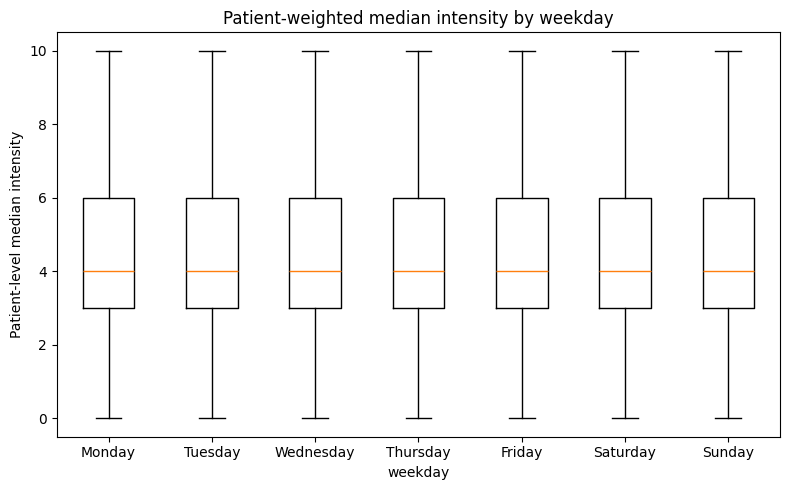

C:\Users\prath\AppData\Local\Temp\ipykernel_28984\2350704479.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels, showfliers=False)


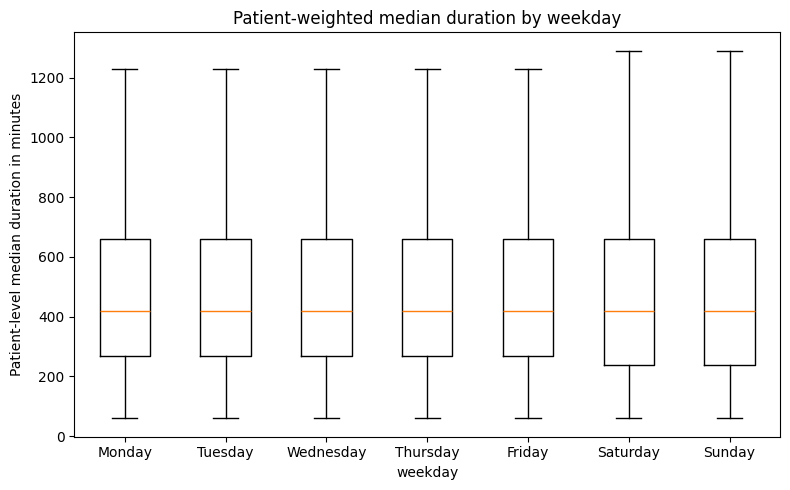

C:\Users\prath\AppData\Local\Temp\ipykernel_28984\2350704479.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels, showfliers=False)


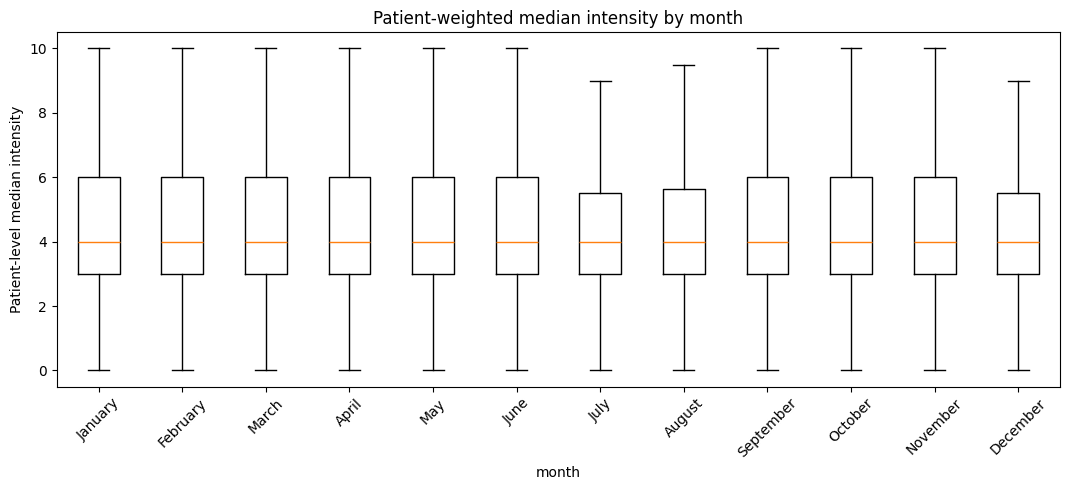

C:\Users\prath\AppData\Local\Temp\ipykernel_28984\2350704479.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels, showfliers=False)


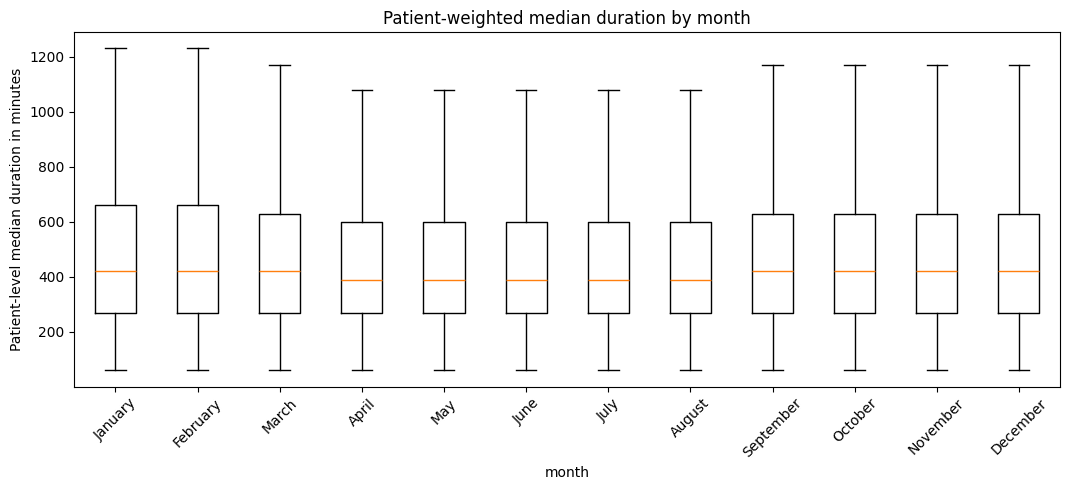

C:\Users\prath\AppData\Local\Temp\ipykernel_28984\2350704479.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels, showfliers=False)


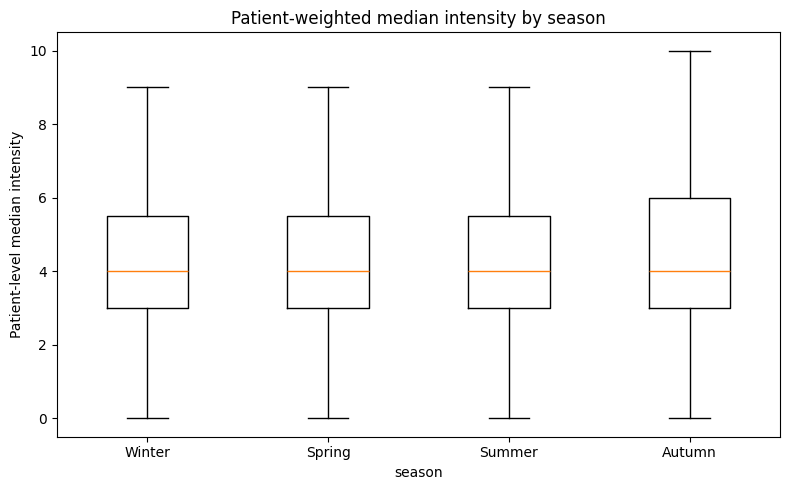

C:\Users\prath\AppData\Local\Temp\ipykernel_28984\2350704479.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels, showfliers=False)


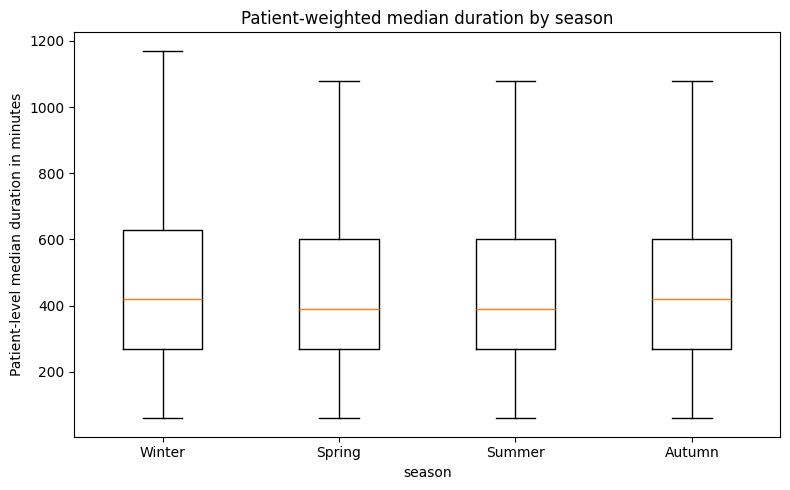

In [34]:
boxplot_patient_weighted(
    patient_weekday_medians,
    "weekday",
    "patient_median_intensity",
    weekday_order,
    "Patient-weighted median intensity by weekday",
    "Patient-level median intensity"
)

boxplot_patient_weighted(
    patient_weekday_medians,
    "weekday",
    "patient_median_duration",
    weekday_order,
    "Patient-weighted median duration by weekday",
    "Patient-level median duration in minutes"
)

boxplot_patient_weighted(
    patient_month_medians,
    "month",
    "patient_median_intensity",
    month_order,
    "Patient-weighted median intensity by month",
    "Patient-level median intensity"
)

boxplot_patient_weighted(
    patient_month_medians,
    "month",
    "patient_median_duration",
    month_order,
    "Patient-weighted median duration by month",
    "Patient-level median duration in minutes"
)

boxplot_patient_weighted(
    patient_season_medians,
    "season",
    "patient_median_intensity",
    season_order,
    "Patient-weighted median intensity by season",
    "Patient-level median intensity"
)

boxplot_patient_weighted(
    patient_season_medians,
    "season",
    "patient_median_duration",
    season_order,
    "Patient-weighted median duration by season",
    "Patient-level median duration in minutes"
)

In [35]:
# ------------------------------------------------------------
# Patient-weighted Kruskal contribution analysis
# ------------------------------------------------------------
# This identifies which groups contribute most to the
# patient-weighted Kruskal-Wallis rank differences.

patient_weighted_driver_tests = [
    (
        patient_weekday_medians,
        "patient_median_intensity",
        "weekday",
        weekday_order
    ),
    (
        patient_month_medians,
        "patient_median_intensity",
        "month",
        month_order
    ),
    (
        patient_season_medians,
        "patient_median_intensity",
        "season",
        season_order
    ),
    (
        patient_weekday_medians,
        "patient_median_duration",
        "weekday",
        weekday_order
    ),
    (
        patient_month_medians,
        "patient_median_duration",
        "month",
        month_order
    ),
    (
        patient_season_medians,
        "patient_median_duration",
        "season",
        season_order
    ),
]

patient_weighted_driver_tables = {}

for df_patient_level, value_col, group_col, group_order in patient_weighted_driver_tests:
    table_name = f"{value_col}_by_{group_col}"

    driver_table = kruskal_group_contributions(
        df=df_patient_level,
        value_col=value_col,
        group_col=group_col,
        group_order=group_order
    )

    patient_weighted_driver_tables[table_name] = driver_table

    print("\n" + "=" * 90)
    print(f"Patient-weighted drivers: {value_col} by {group_col}")
    print("=" * 90)

    display(driver_table)


Patient-weighted drivers: patient_median_intensity by weekday


,weekday,n,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
6,Sunday,49137,4.0,3.0,6.0,3.0,0.0,174029.976,-2051.024,lower than overall,33.25
3,Thursday,50919,4.0,3.0,6.0,3.0,0.0,177550.160,1469.160,higher than overall,17.68
1,Tuesday,50632,4.0,3.0,6.0,3.0,0.0,174785.550,-1295.450,lower than overall,13.67
5,Saturday,49721,4.0,3.0,6.0,3.0,0.0,177385.594,1304.594,higher than overall,13.61
4,Friday,50266,4.0,3.0,6.0,3.0,0.0,177201.462,1120.462,higher than overall,10.15
0,Monday,50392,4.0,3.0,6.0,3.0,0.0,174990.838,-1090.162,lower than overall,9.63
2,Wednesday,51094,4.0,3.0,6.0,3.0,0.0,176576.417,495.417,higher than overall,2.02



Patient-weighted drivers: patient_median_intensity by month


,month,n,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
9,October,29830,4.0,3.0,6.000,3.000,0.0,171924.796,1534.796,higher than overall,40.60
6,July,27021,4.0,3.0,5.500,2.500,0.0,169321.805,-1068.195,lower than overall,17.81
2,March,23543,4.0,3.0,6.000,3.000,0.0,171364.628,974.628,higher than overall,12.92
7,August,27452,4.0,3.0,5.625,2.625,0.0,169706.973,-683.027,lower than overall,7.40
3,April,24190,4.0,3.0,6.000,3.000,0.0,171085.042,695.042,higher than overall,6.75
11,December,30894,4.0,3.0,5.500,2.500,0.0,169836.688,-553.312,lower than overall,5.46
5,June,25733,4.0,3.0,6.000,3.000,0.0,169893.700,-496.300,lower than overall,3.66
4,May,25275,4.0,3.0,6.000,3.000,0.0,170000.824,-389.176,lower than overall,2.21
1,February,33328,4.0,3.0,6.000,3.000,0.0,170056.659,-333.341,lower than overall,2.14
8,September,28548,4.0,3.0,6.000,3.000,0.0,170550.349,160.349,higher than overall,0.42



Patient-weighted drivers: patient_median_intensity by season


...

,weekday,n,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
3,Thursday,50919,420.0,270.0,660.0,390.0,0.0,178003.410,1922.410,higher than overall,42.08
5,Saturday,49721,420.0,240.0,660.0,420.0,0.0,174615.639,-1465.361,lower than overall,23.87
6,Sunday,49137,420.0,240.0,660.0,420.0,0.0,174628.084,-1452.916,lower than overall,23.19
2,Wednesday,51094,420.0,270.0,660.0,390.0,0.0,176926.439,845.439,higher than overall,8.17
4,Friday,50266,420.0,270.0,660.0,390.0,0.0,176462.058,381.058,higher than overall,1.63
0,Monday,50392,420.0,270.0,660.0,390.0,0.0,175775.320,-305.680,lower than overall,1.05
1,Tuesday,50632,420.0,270.0,660.0,390.0,0.0,176069.480,-11.520,lower than overall,0.00



Patient-weighted drivers: patient_median_duration by month


,month,n,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
5,June,25733,390.0,270.0,600.0,330.0,-30.0,167142.486,-3247.514,lower than overall,26.24
1,February,33328,420.0,270.0,660.0,390.0,0.0,172848.771,2458.771,higher than overall,19.48
6,July,27021,390.0,270.0,600.0,330.0,-30.0,168238.645,-2151.355,lower than overall,12.09
7,August,27452,390.0,270.0,600.0,330.0,-30.0,168300.343,-2089.657,lower than overall,11.59
0,January,34014,420.0,270.0,660.0,390.0,0.0,172121.697,1731.697,higher than overall,9.86
4,May,25275,390.0,270.0,600.0,330.0,-30.0,168748.481,-1641.519,lower than overall,6.58
9,October,29830,420.0,270.0,630.0,360.0,0.0,171797.667,1407.667,higher than overall,5.72
2,March,23543,420.0,270.0,630.0,360.0,0.0,171627.084,1237.084,higher than overall,3.48
3,April,24190,390.0,270.0,600.0,330.0,-30.0,169459.394,-930.606,lower than overall,2.03
8,September,28548,420.0,270.0,630.0,360.0,0.0,171137.127,747.127,higher than overall,1.54



Patient-weighted drivers: patient_median_duration by season


,season,n,median,q1,q3,iqr,median_difference_from_overall,mean_rank,mean_rank_difference_from_overall,rank_direction,contribution_percent
2,Summer,34597,390.0,270.0,600.0,330.0,0.0,72741.560,-1053.440,lower than overall,53.54
0,Winter,42573,420.0,270.0,630.0,360.0,30.0,74543.418,748.418,higher than overall,33.25
3,Autumn,38622,420.0,270.0,600.0,330.0,30.0,74187.660,392.660,higher than overall,8.30
1,Spring,31797,390.0,270.0,600.0,330.0,0.0,73462.206,-332.794,lower than overall,4.91


In [36]:
patient_weighted_top_driver_summary_list = []

for df_patient_level, value_col, group_col, group_order in patient_weighted_driver_tests:
    table_name = f"{value_col}_by_{group_col}"
    driver_table = patient_weighted_driver_tables[table_name]

    top_groups = driver_table.head(3).copy()

    for _, row in top_groups.iterrows():
        patient_weighted_top_driver_summary_list.append({
            "outcome": value_col,
            "group_variable": group_col,
            "driver_group": row[group_col],
            "median": row["median"],
            "median_difference_from_overall": row["median_difference_from_overall"],
            "rank_direction": row["rank_direction"],
            "contribution_percent": row["contribution_percent"]
        })

patient_weighted_top_driver_summary = pd.DataFrame(
    patient_weighted_top_driver_summary_list
)

display(patient_weighted_top_driver_summary)

,outcome,group_variable,driver_group,median,median_difference_from_overall,rank_direction,contribution_percent
0,patient_median_intensity,weekday,Sunday,4.0,0.0,lower than overall,33.25
1,patient_median_intensity,weekday,Thursday,4.0,0.0,higher than overall,17.68
2,patient_median_intensity,weekday,Tuesday,4.0,0.0,lower than overall,13.67
3,patient_median_intensity,month,October,4.0,0.0,higher than overall,40.60
4,patient_median_intensity,month,July,4.0,0.0,lower than overall,17.81
5,patient_median_intensity,month,March,4.0,0.0,higher than overall,12.92
6,patient_median_intensity,season,Autumn,4.0,0.0,higher than overall,68.13
7,patient_median_intensity,season,Summer,4.0,0.0,lower than overall,21.23
8,patient_median_intensity,season,Winter,4.0,0.0,lower than overall,10.31
9,patient_median_duration,weekday,Thursday,420.0,0.0,higher than overall,42.08
